In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline

## Loading the dataset

In [26]:
df_title=pd.read_csv('titles.csv')
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"['fantasy', 'family']",['US'],NaN,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,['drama'],['US'],NaN,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"['drama', 'romance', 'war']",['US'],NaN,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,NaN,116,"['thriller', 'crime']",['US'],NaN,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,NaN,100,"['thriller', 'romance', 'crime']",['US'],NaN,tt0033870,8.0,156603.0,12.788,7.8


In [27]:
df_title.shape

(3294, 15)

In [28]:
df_title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3294 entries, 0 to 3293
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3294 non-null   object 
 1   title                 3294 non-null   object 
 2   type                  3294 non-null   object 
 3   description           3282 non-null   object 
 4   release_year          3294 non-null   int64  
 5   age_certification     2086 non-null   object 
 6   runtime               3294 non-null   int64  
 7   genres                3294 non-null   object 
 8   production_countries  3294 non-null   object 
 9   seasons               756 non-null    float64
 10  imdb_id               2968 non-null   object 
 11  imdb_score            2922 non-null   float64
 12  imdb_votes            2911 non-null   float64
 13  tmdb_popularity       3261 non-null   float64
 14  tmdb_score            3026 non-null   float64
dtypes: float64(5), int64(

In [29]:
df_title.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,3294.000000,3294.000000,756.000000,2922.000000,2.911000e+03,3261.000000,3026.000000
mean,2001.194293,80.914997,2.998677,6.883949,6.461835e+04,21.105891,6.850099
std,23.542337,38.475347,3.651181,1.059668,1.754617e+05,89.137800,1.081377
min,1901.000000,1.000000,1.000000,1.500000,5.000000e+00,0.050393,1.000000
25%,1995.000000,51.250000,1.000000,6.300000,9.245000e+02,3.450000,6.200000
50%,2010.000000,89.000000,2.000000,7.000000,8.071000e+03,8.561000,6.900000
75%,2018.000000,106.000000,4.000000,7.600000,4.764500e+04,17.711000,7.500000
max,2022.000000,255.000000,52.000000,9.400000,2.555504e+06,4447.894000,10.000000


## Initial Exploration

In [30]:
numerical_features=[feature for feature in df_title.columns if df_title[feature].dtype !='O']
categorical_features=[feature for feature in df_title.columns if df_title[feature].dtype == 'O']
print(f'categorical features:',categorical_features)
print(f'numerical features:',numerical_features)

categorical features: ['id', 'title', 'type', 'description', 'age_certification', 'genres', 'production_countries', 'imdb_id']
numerical features: ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']


In [31]:
for col in categorical_features:
    print(col)
    print(df_title[col].unique())
    print('-------------')
   
    

id
['tm155702' 'tm83648' 'tm77588' ... 'tm1121489' 'tm1121486' 'tm989132']
-------------
title
['The Wizard of Oz' 'Citizen Kane' 'Casablanca' ...
 'Entre Nos: What She Said' 'Entre Nos: The Winners 2'
 'The Infamous Future']
-------------
type
['MOVIE' 'SHOW']
-------------
description
['Young Dorothy finds herself in a magical world where she makes friends with a lion, a scarecrow and a tin man as they make their way along the yellow brick road to talk with the Wizard and ask for the things they miss most in their lives. The Wicked Witch of the West is the only thing that could stop them.'
 'Newspaper magnate, Charles Foster Kane is taken from his mother as a boy and made the ward of a rich industrialist. As a result, every well-meaning, tyrannical or self-destructive move he makes for the rest of his life appears in some way to be a reaction to that deeply wounding event.'
 'In Casablanca, Morocco in December 1941, a cynical American expatriate meets a former lover, with unforeseen 

In [32]:
df_title['genres'].unique()

array(["['fantasy', 'family']", "['drama']",
       "['drama', 'romance', 'war']", ...,
       "['fantasy', 'family', 'animation']",
       "['family', 'fantasy', 'animation', 'comedy']",
       "['romance', 'music']"], dtype=object)

## Data cleaning

In [33]:
df_title.isnull().sum()

id                         0
title                      0
type                       0
description               12
release_year               0
age_certification       1208
runtime                    0
genres                     0
production_countries       0
seasons                 2538
imdb_id                  326
imdb_score               372
imdb_votes               383
tmdb_popularity           33
tmdb_score               268
dtype: int64

In [34]:
df_title.shape

(3294, 15)

In [35]:
df_title['seasons']=df_title['seasons'].fillna(0)

In [36]:
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"['fantasy', 'family']",['US'],0.0,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,['drama'],['US'],0.0,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"['drama', 'romance', 'war']",['US'],0.0,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,NaN,116,"['thriller', 'crime']",['US'],0.0,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,NaN,100,"['thriller', 'romance', 'crime']",['US'],0.0,tt0033870,8.0,156603.0,12.788,7.8


In [37]:
df_title['age_certification']=df_title['age_certification'].fillna('Unknown')

In [38]:
df_title.dropna(subset=['imdb_id'], inplace=True)

In [39]:
df_title.isnull().sum()

id                        0
title                     0
type                      0
description               5
release_year              0
age_certification         0
runtime                   0
genres                    0
production_countries      0
seasons                   0
imdb_id                   0
imdb_score               46
imdb_votes               57
tmdb_popularity          31
tmdb_score              187
dtype: int64

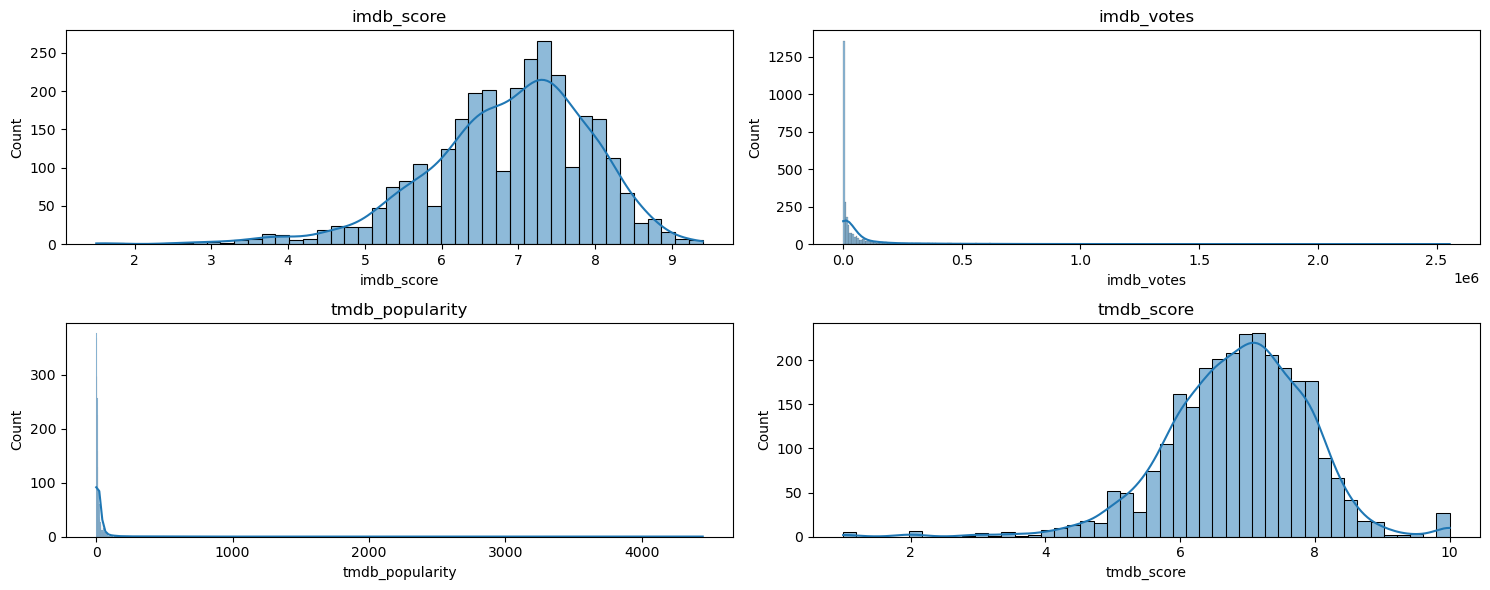

In [40]:
#Normally distributed-use mean
#skewed or has outliers-median
#imbd_score-right skewed
#imdb_vostes-left skewed
#tmdb_popularity-left skewed
#tmdb_score-right skewed
#Use median imputation to handle missing values for all the features above.
plt.figure(figsize=(15,6))
features=['imdb_score','imdb_votes','tmdb_popularity','tmdb_score']
for i in range(0,len(features)):
    plt.subplot(2,2,i+1)
    sns.histplot(df_title[features[i]],kde=True)
    plt.title(features[i])
plt.tight_layout()
plt.show()

In [41]:
df_title['imdb_score']=df_title['imdb_score'].fillna(df_title['imdb_score'].median())
df_title['imdb_votes']=df_title['imdb_votes'].fillna(df_title['imdb_votes'].median())
df_title['tmdb_score']=df_title['tmdb_score'].fillna(df_title['tmdb_score'].median())
df_title['tmdb_popularity']=df_title['tmdb_popularity'].fillna(df_title['tmdb_popularity'].median())




In [50]:
df_title['description']=df_title['description'].fillna('None')

In [51]:
df_title.isnull().sum()

id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
dtype: int64

Checking and handling duplicates


In [43]:
df_title[df_title.duplicated()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score


In [44]:
df_title.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2968 entries, 0 to 3293
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2968 non-null   object 
 1   title                 2968 non-null   object 
 2   type                  2968 non-null   object 
 3   description           2963 non-null   object 
 4   release_year          2968 non-null   int64  
 5   age_certification     2968 non-null   object 
 6   runtime               2968 non-null   int64  
 7   genres                2968 non-null   object 
 8   production_countries  2968 non-null   object 
 9   seasons               2968 non-null   float64
 10  imdb_id               2968 non-null   object 
 11  imdb_score            2968 non-null   float64
 12  imdb_votes            2968 non-null   float64
 13  tmdb_popularity       2968 non-null   float64
 14  tmdb_score            2968 non-null   float64
dtypes: float64(5), int64(2), o

In [48]:
df_title['genres']=df_title['genres'].str.replace(r"[\[\]']","",regex=True)
df_title['production_countries']=df_title['production_countries'].str.replace(r"[\[\]']","",regex=True)

In [52]:
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,drama,US,0.0,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"drama, romance, war",US,0.0,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,Unknown,116,"thriller, crime",US,0.0,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,Unknown,100,"thriller, romance, crime",US,0.0,tt0033870,8.0,156603.0,12.788,7.8


In [53]:
df_title['production_countries'].unique()

array(['US', 'JP', 'GB', 'DE', 'IT', 'FR', 'SE', 'FR, DE', 'SU', 'GB, CA',
       'FR, US', 'IT, US', 'IT, XG, FR, DE', 'CH', 'DK', '', 'US, GB',
       'GB, US', 'CA', 'XC, FR', 'IT, FR', 'FR, IT', 'IT, DZ', 'AU',
       'DE, IR, FR', 'FR, BE', 'XC', 'IN', 'ES, CH', 'DZ, FR',
       'BR, FR, IT', 'DE, SE, FR', 'PL', 'SE, FR', 'FR, SN', 'JP, US',
       'BE, FR, DE', 'IN, US, FR', 'ES, CH, FR', 'FR, SU', 'SN', 'US, HK',
       'MX', 'ES, US', 'AT', 'NO', 'HK, US', 'US, MX', 'US, ES, GB, IT',
       'CA, US', 'FR, GB, DE', 'HK', 'US, CA', 'US, CA, IL', 'US, BE',
       'US, NL', 'FR, IT, GB, CN', 'GB, US, IE', 'ES', 'SE, DE, FR',
       'US, AU', 'FR, DE, PL', 'DE, US', 'DE, FR, IT', 'MX, US', 'FR, CH',
       'US, DE', 'GB, NZ, AU', 'AR', 'CA, IL', 'DE, FR', 'XX', 'KR',
       'CN, HK', 'JP, US, DE', 'FR, US, CA', 'US, GB, JP', 'US, JP',
       'JP, GB, IE', 'BE', 'JP, AR, HK', 'FR, GB', 'NZ, GB, US, DK, FR',
       'FR, PL, CH', 'GB, US, DE, JP, NZ', 'JP, GB, US, DE',
       'NL, NO, 

In [54]:
#Remove extra spaces.
df_title['production_countries']=df_title['production_countries'].str.replace(' ','')

In [55]:
df_title['production_countries'].unique()

array(['US', 'JP', 'GB', 'DE', 'IT', 'FR', 'SE', 'FR,DE', 'SU', 'GB,CA',
       'FR,US', 'IT,US', 'IT,XG,FR,DE', 'CH', 'DK', '', 'US,GB', 'GB,US',
       'CA', 'XC,FR', 'IT,FR', 'FR,IT', 'IT,DZ', 'AU', 'DE,IR,FR',
       'FR,BE', 'XC', 'IN', 'ES,CH', 'DZ,FR', 'BR,FR,IT', 'DE,SE,FR',
       'PL', 'SE,FR', 'FR,SN', 'JP,US', 'BE,FR,DE', 'IN,US,FR',
       'ES,CH,FR', 'FR,SU', 'SN', 'US,HK', 'MX', 'ES,US', 'AT', 'NO',
       'HK,US', 'US,MX', 'US,ES,GB,IT', 'CA,US', 'FR,GB,DE', 'HK',
       'US,CA', 'US,CA,IL', 'US,BE', 'US,NL', 'FR,IT,GB,CN', 'GB,US,IE',
       'ES', 'SE,DE,FR', 'US,AU', 'FR,DE,PL', 'DE,US', 'DE,FR,IT',
       'MX,US', 'FR,CH', 'US,DE', 'GB,NZ,AU', 'AR', 'CA,IL', 'DE,FR',
       'XX', 'KR', 'CN,HK', 'JP,US,DE', 'FR,US,CA', 'US,GB,JP', 'US,JP',
       'JP,GB,IE', 'BE', 'JP,AR,HK', 'FR,GB', 'NZ,GB,US,DK,FR',
       'FR,PL,CH', 'GB,US,DE,JP,NZ', 'JP,GB,US,DE',
       'NL,NO,ES,SE,GB,DK,FR,IS', 'GB,US,FR,IT,JP', 'FR,JP,GB,US,DE',
       'PL,FR', 'FR,IR', 'AU,US', 'AT,CH', 'SE

In [56]:
#Handling outliers
numerical_features

['release_year',
 'runtime',
 'seasons',
 'imdb_score',
 'imdb_votes',
 'tmdb_popularity',
 'tmdb_score']

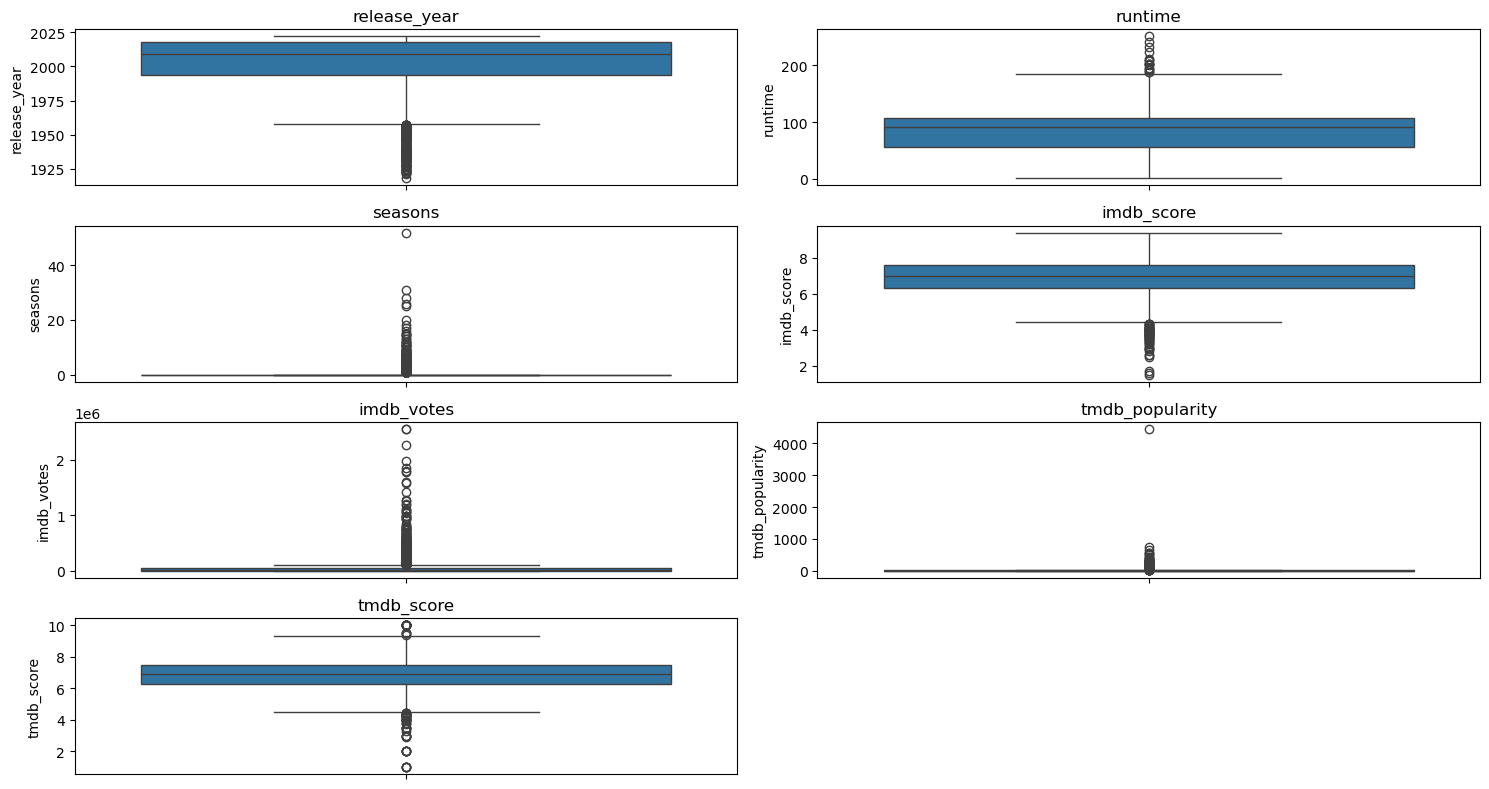

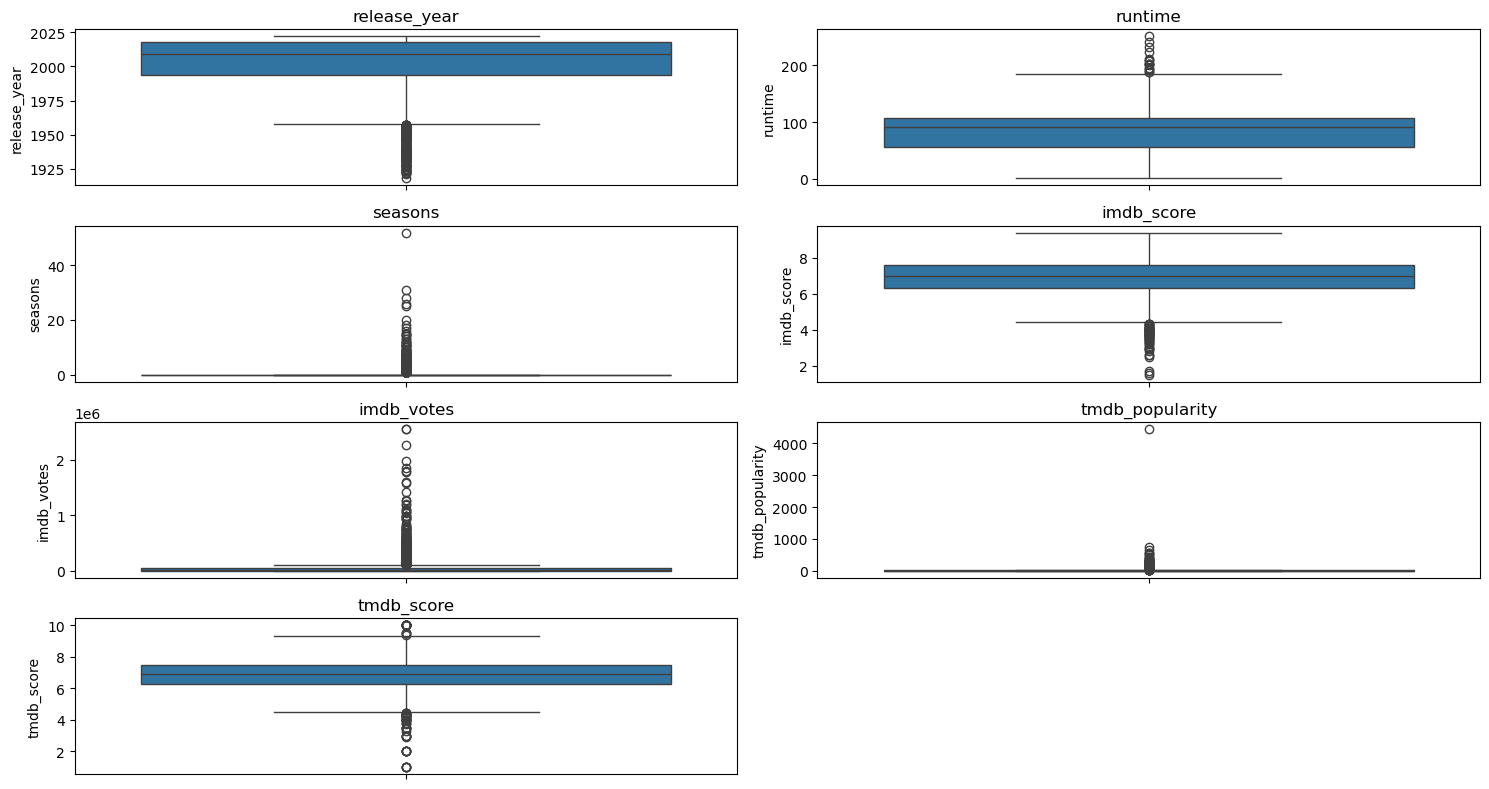

In [ ]:

plt.figure(figsize=(15,8))
for i in range(0,len(numerical_features)):
    plt.subplot(4, 2, i+1)
    sns.boxplot(y=df_title[numerical_features[i]])
    plt.title(numerical_features[i])
plt.tight_layout()
plt.show()

Outlier analysis was performed using boxplots. Extreme values were observed in tmdb_popularity and imdb_votes feature; 
however,these values represent genuine differences in movie popularity and were retained